### Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from pipeline_utils import make_case4_paths, binarize_mutation_inclusive

paths = make_case4_paths()

## Input files (from 0_xevaset_extraction/UHN_breast_XevaSet_extraction.R)
batch_sensitivity_file = paths["datasets"] / "uhn_breast" / "batch_sensitivity.csv"
model_sensitivity_file = paths["datasets"] / "uhn_breast" / "model_sensitivity.csv"
expdesign_file = paths["datasets"] / "uhn_breast" / "expDesign.csv"
rna_file = paths["datasets"] / "uhn_breast" / "RNASeq_matrix.csv"
cnv_file = paths["datasets"] / "uhn_breast" / "CNV_matrix.csv"
mutation_file = paths["datasets"] / "uhn_breast" / "mutation_matrix.csv"

## Output files
metadata_out = paths["proc"] / "metadata.csv"
rna_out = paths["proc"] / "rna_logtpm.csv"
cnv_out = paths["proc"] / "cnv.csv"
mutation_out = paths["proc"] / "mutation.csv"

### Drug sensitivity info extraction

In [2]:
batch_sen = pd.read_csv(batch_sensitivity_file)
model_sen = pd.read_csv(model_sensitivity_file)
exp_dsg = pd.read_csv(expdesign_file)

treatment_arm = exp_dsg[exp_dsg["arm"] == "treatment"]

# n_replicates: number of treatment-arm mice recorded per batch in expDesign.csv
n_replicates_derived = (
    treatment_arm.groupby("batch.name").size().rename("n_replicates").reset_index()
)

# mRECIST: model_sensitivity.csv records it per individual mouse, not per batch.
# Aggregate to one value per batch via majority vote across that batch's
# treatment-arm mice; ties broken by worst response (PD > SD > PR > CR).
# (Same method as 3_carboplatin's UHN/McGill notebooks.) Kept only as a
# reference/QC column -- the actual response label used for modeling is a
# fixed slope.treatment < 0 cutoff, matching case 3 (see feature_sets.py).
MRECIST_WORST_FIRST = ["PD", "SD", "PR", "CR"]

def majority_vote_mrecist(values):
    counts = values.dropna().value_counts()
    if counts.empty:
        return None
    top_count = counts.max()
    tied = counts[counts == top_count].index
    return next(r for r in MRECIST_WORST_FIRST if r in tied)

mouse_mrecist = treatment_arm.merge(model_sen[["model.id", "mRECIST"]], on="model.id", how="left")
mrecist_derived = (
    mouse_mrecist.groupby("batch.name")["mRECIST"]
    .apply(majority_vote_mrecist)
    .rename("mRECIST")
    .reset_index()
)

# batch name contains PACLITAXEL but not resistant-derivative lines ("-"/"RES")
pax = batch_sen[
    batch_sen["batch.name"].str.contains("PACLITAXEL")
    & ~batch_sen["batch.name"].str.contains("-")
    & ~batch_sen["batch.name"].str.contains("RES")
].reset_index(drop=True)

pax["model.id"] = pax["batch.name"].str.split(".").str[0]
pax["drug.id"] = pax["batch.name"].str.split(".").str[1]

# Omics sample IDs are prefixed "S" for numeric model IDs
mask = pax["model.id"].str.match(r'^\d', na=False)
pax.loc[mask, "model.id"] = "S" + pax.loc[mask, "model.id"]

pax = pax.merge(n_replicates_derived, on="batch.name", how="left")
pax = pax.merge(mrecist_derived, on="batch.name", how="left")

n_multi_arm = (pax["n_replicates"] > 1).sum()
print(f"Paclitaxel batches with multiple treatment-arm entries (majority vote applies): {n_multi_arm}/{len(pax)}")

print(pax["mRECIST"].value_counts())

# A model's mRECIST can be missing if none of its treatment-arm mice have a
# recorded mRECIST in model_sensitivity.csv -- kept in the cohort, just flagged.
missing_mrecist = pax.loc[pax["mRECIST"].isna(), "model.id"].tolist()
if missing_mrecist:
    print(f"\nModels kept but with no recorded mRECIST: {missing_mrecist}")

print(f"\nn_replicates distribution across the {len(pax)} paclitaxel batches:")
print(pax["n_replicates"].value_counts().sort_index())

# Restrict to the columns downstream cells expect. slope.treatment is the
# response used for modeling (fixed 0 deg cutoff, matching case 3); angle is
# kept alongside it for reference/QC plots; mRECIST is kept only as a
# reference/QC column. n_replicates/drug.id are QC-only here, not persisted,
# so they don't leak into the omics feature matrices merged against this
# table below.
pax = pax[["model.id", "angle", "slope.treatment", "mRECIST"]].set_index("model.id")
pax.to_csv(metadata_out)

Paclitaxel batches with multiple treatment-arm entries (majority vote applies): 49/80
mRECIST
SD    29
CR    22
PD    18
PR    11
Name: count, dtype: int64

n_replicates distribution across the 80 paclitaxel batches:
n_replicates
1     31
2     19
3     17
4      4
5      1
6      1
7      1
9      1
10     2
14     1
17     1
23     1
Name: count, dtype: int64


### RNAseq data

In [3]:
# read in the RNA-seq data
rna = pd.read_csv(rna_file, index_col=0)

rna = rna.transpose()
print(f"Models in RNA-seq: {len(rna)}")
rna = np.log2(rna + 1)

# remove genes with no variance across all available RNA-seq samples
rna = rna.loc[:, rna.var() > 0]

# merge with paclitaxel response metadata
df_rna_pax = rna.merge(pax, left_index=True, right_index=True, how="inner")

# remove genes with no variance within the paclitaxel subset
response_cols = ["angle", "slope.treatment", "mRECIST"]
X = df_rna_pax.drop(columns=response_cols)
y = df_rna_pax[response_cols]
X = X.loc[:, X.var() > 0]
df_rna_pax = X.merge(y, left_index=True, right_index=True)

print(f"Models in pax list: {len(pax)}")
print(f"Models in Final DF: {df_rna_pax.shape[0]}")
print(f"RNA genes after paclitaxel subset zero-variance filter: {X.shape[1]}")

df_rna_pax.to_csv(rna_out)
print(df_rna_pax.shape)

Models in RNA-seq: 95
Models in pax list: 80
Models in Final DF: 67
RNA genes after paclitaxel subset zero-variance filter: 49348


(67, 49351)


### CNV data

In [4]:
# read in the CNV data (absolute copy number, genes x samples)
cnv = pd.read_csv(cnv_file, index_col=0)

# restrict to the paclitaxel cohort's samples up front, so the per-sample
# baseline below reflects only the models actually used downstream
cnv = cnv[cnv.columns.intersection(pax.index)]
print(f"Models in CNV before filtering: {cnv.shape[1]}")

# Per-sample baseline copy number (modal CN across the full genome, computed
# before any gene-level filtering below -- same order of operations as
# 3_carboplatin's UHN notebook, so the baseline reflects all available
# genome-wide data rather than only genes that pass the missingness filter).
# UHN CNV is not diploid at baseline for most samples; see case 3 for the
# full justification.
cnv_baseline = cnv.mode(axis=0, dropna=True).iloc[0]
print(f"Per-sample baseline copy number (modal): {cnv_baseline.value_counts().sort_index().to_dict()}")

# remove genes with high missingness across samples
missing_rate = cnv.isna().mean(axis=1)
cnv = cnv.loc[missing_rate < 0.20]
print(f"CNV genes after missingness filter: {cnv.shape[0]}")

# Ploidy-relative log2 ratio: 0 = at this sample's own baseline, positive =
# amplified relative to baseline, negative = deleted relative to baseline.
# Baseline is floored at 1 (avoids divide-by-zero for the few samples whose
# own baseline is 0, more likely low tumor purity than genuine haploid
# biology) and a +0.5 pseudocount avoids -inf for homozygous deletions (CN=0).
# This keeps the graded magnitude information a binary amp/del call would
# lose, while still correcting for each sample's own ploidy.
baseline_floor = cnv_baseline.clip(lower=1)
cnv_ratio = np.log2((cnv + 0.5).div(baseline_floor, axis=1))

# remaining missing values -> 0 (i.e. "at this sample's own baseline", the
# neutral value on this ratio scale)
cnv_ratio = cnv_ratio.fillna(0)

# transpose to samples x genes
cnv_ratio = cnv_ratio.transpose()

# remove genes with no variance across all available CNV samples
cnv_ratio = cnv_ratio.loc[:, cnv_ratio.var() > 0]
print(f"CNV genes after global zero-variance filter: {cnv_ratio.shape[1]}")

# merge with paclitaxel response metadata
df_cnv_pax = cnv_ratio.merge(pax, left_index=True, right_index=True, how="inner")

# remove genes with no variance within the paclitaxel subset
response_cols = ["angle", "slope.treatment", "mRECIST"]
X = df_cnv_pax.drop(columns=response_cols)
y = df_cnv_pax[response_cols]
X = X.loc[:, X.var() > 0]
df_cnv_pax = X.merge(y, left_index=True, right_index=True)

print(f"Models in pax list: {len(pax)}")
print(f"Models in Final DF: {df_cnv_pax.shape[0]}")
print(f"CNV genes after paclitaxel subset zero-variance filter: {X.shape[1]}")

# save processed CNV + response table
df_cnv_pax.to_csv(cnv_out)
print(df_cnv_pax.shape)

Models in CNV before filtering: 62
Per-sample baseline copy number (modal): {0.0: 3, 1.0: 7, 3.0: 40, 4.0: 4, 5.0: 5, 6.0: 2, 7.0: 1}
CNV genes after missingness filter: 10313
CNV genes after global zero-variance filter: 10313
Models in pax list: 80
Models in Final DF: 62
CNV genes after paclitaxel subset zero-variance filter: 10313


(62, 10316)


### Mutation data

In [5]:
# read in the Mutation data
mutation = pd.read_csv(mutation_file, index_col=0)

mutation = mutation.transpose()

# Binarize: 1 if any functional variant classification is present, else 0
# (same inclusive whitelist as 3_carboplatin/pipeline_utils.py)
mutation = mutation.map(binarize_mutation_inclusive)

print(f"Models in Mutation: {len(mutation)}")

# remove genes with no variance across all available mutation samples
mutation = mutation.loc[:, mutation.var() > 0]

# merge with paclitaxel response metadata
df_mutation_pax = mutation.merge(pax, left_index=True, right_index=True, how="inner")

# remove genes with no variance within the paclitaxel subset
response_cols = ["angle", "slope.treatment", "mRECIST"]
X = df_mutation_pax.drop(columns=response_cols)
y = df_mutation_pax[response_cols]
X = X.loc[:, X.var() > 0]
df_mutation_pax = X.merge(y, left_index=True, right_index=True)

print(f"Models in pax list: {len(pax)}")
print(f"Models in Final DF: {df_mutation_pax.shape[0]}")
print(f"Mutation genes after paclitaxel subset zero-variance filter: {X.shape[1]}")

df_mutation_pax.to_csv(mutation_out)
print(df_mutation_pax.shape)

Models in Mutation: 91
Models in pax list: 80
Models in Final DF: 62
Mutation genes after paclitaxel subset zero-variance filter: 13029
(62, 13032)


### Window-choice justification: is the default response window reasonable?

The `angle` column above comes directly from `batch_sensitivity.csv`, which reflects Xeva's default sensitivity slot for this XevaSet -- the full observed treatment duration, not any fixed response window. This is the same underlying UHN XevaSet used by case study 3, where this was found to reflect highly variable, undocumented follow-up (up to 286 days for the carboplatin arm); the paclitaxel batches used here have an even wider spread (21-538 days, median 135).

Rather than picking a response window by whichever choice maximizes downstream model performance (circular), we check the same two things case 1's MAX_DAY justification and case 3's window-choice diagnostic did: (i) whether the *uncensored* angle is confounded with how long a model happened to be followed, and (ii) how the *median* angle drifts as the candidate window widens, taking the **deepest point** -- the most extreme median response, before wider windows fold in regrowth/relapse dynamics and erode it -- as the chosen cutoff, the same criterion case 3 used to select McGill's 28-day window. `min.time = 10` is held fixed (inherited from case 3's structural justification: it is a property of Xeva's mRECIST algorithm, not something specific to a drug or cohort, so it is not re-derived here), and `max.time` is swept in the same weekly steps from 14 to 56 days used for case 3's own sweep (see `window_confound_sweep.R`).

In [6]:
def batch_followup_duration(batch_names):
    """Per-batch, treatment-arm follow-up duration, uncensored by any response window
    (max over replicate mice within a batch, matching Xeva's batch-level aggregation unit)."""
    exp = pd.read_csv(paths["datasets"] / "uhn_breast" / "experiment.csv").set_index("model.id")
    design = pd.read_csv(paths["datasets"] / "uhn_breast" / "expDesign.csv")
    treatment = design[design["batch.name"].isin(batch_names) & (design["arm"] == "treatment")]

    rows = []
    for batch_name, grp in treatment.groupby("batch.name"):
        days = [exp.loc[[m], "time"].max() for m in grp["model.id"] if m in exp.index]
        if days:
            rows.append({"batch.name": batch_name, "last_observed_day": max(days)})
    return pd.DataFrame(rows)


pax_full_duration = pd.read_csv(paths["proc"] / "paclitaxel_angle_full_duration.csv")
pax_followup = batch_followup_duration(pax_full_duration["batch.name"].unique())
print(f"Paclitaxel: n={len(pax_followup)}, median follow-up={pax_followup['last_observed_day'].median():.0f} days, "
      f"max={pax_followup['last_observed_day'].max():.0f}")

Paclitaxel: n=80, median follow-up=135 days, max=538


75% of batches followed beyond day 49
Uncensored angle vs. follow-up day: rho=0.627, p=4.93e-10, n=80
Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/case4_window_confound_diagnostic.png


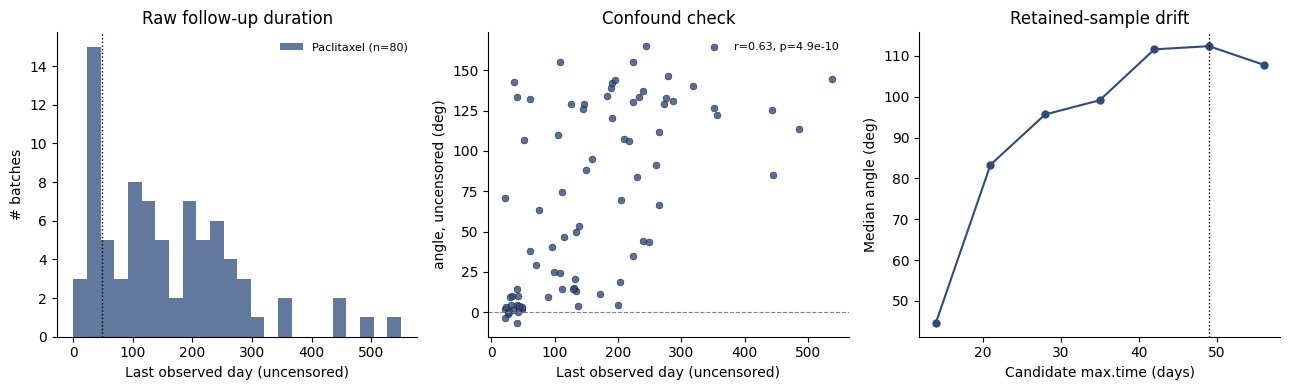

In [7]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

CHOSEN_MAX_TIME = 49
PAX_COLOR = "#2F4B7C"

pax_sweep = pd.read_csv(paths["proc"] / "paclitaxel_angle_sweep.csv")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Panel 1: raw follow-up duration
ax = axes[0]
bins = np.linspace(0, 550, 25)
ax.hist(pax_followup["last_observed_day"], bins=bins, alpha=0.75, color=PAX_COLOR,
        label=f"Paclitaxel (n={len(pax_followup)})")
pct_past = (pax_followup["last_observed_day"] > CHOSEN_MAX_TIME).mean() * 100
print(f"{pct_past:.0f}% of batches followed beyond day {CHOSEN_MAX_TIME}")
ax.axvline(CHOSEN_MAX_TIME, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("Last observed day (uncensored)")
ax.set_ylabel("# batches")
ax.set_title("Raw follow-up duration")
ax.legend(frameon=False, fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel 2: confound check -- uncensored angle vs. follow-up day
ax = axes[1]
m = pax_followup.merge(pax_full_duration, on="batch.name").dropna(subset=["last_observed_day", "angle"])
rho, p = spearmanr(m["last_observed_day"], m["angle"])
ax.scatter(m["last_observed_day"], m["angle"], color=PAX_COLOR,
           edgecolor="black", linewidth=0.3, s=25, alpha=0.8, label=f"r={rho:.2f}, p={p:.1e}")
print(f"Uncensored angle vs. follow-up day: rho={rho:.3f}, p={p:.2e}, n={len(m)}")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Last observed day (uncensored)")
ax.set_ylabel("angle, uncensored (deg)")
ax.set_title("Confound check")
ax.legend(frameon=False, fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel 3: retained-sample median drift across the weekly max.time sweep
ax = axes[2]
drift = pax_sweep.groupby("max_time")["angle"].median()
ax.plot(drift.index, drift.values, color=PAX_COLOR, marker="o", markersize=5)
ax.axvline(CHOSEN_MAX_TIME, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("Candidate max.time (days)")
ax.set_ylabel("Median angle (deg)")
ax.set_title("Retained-sample drift")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
out_path = paths["figures"] / "case4_window_confound_diagnostic.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

#### Same diagnostic, using `slope.treatment` instead of `angle`

Case study 3 uses the raw treatment-arm slope (not the control/treatment divergence angle) as its response endpoint. Repeating the diagnostic on `slope.treatment` shows both quantities agree on where the deepest point falls: `angle` peaks (112.4 degrees) and `slope.treatment` troughs (-41.5 degrees) at the same max.time = 49 days -- opposite sign because slope.treatment is negative-going where angle is positive-going for a responding model, but the same 7-week window emerges independently from two differently-constructed response quantities, which is a reasonable check on this choice.

Uncensored slope.treatment vs. follow-up day: rho=-0.639, p=1.76e-10, n=80
Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/case4_window_confound_diagnostic_slope_treatment.png


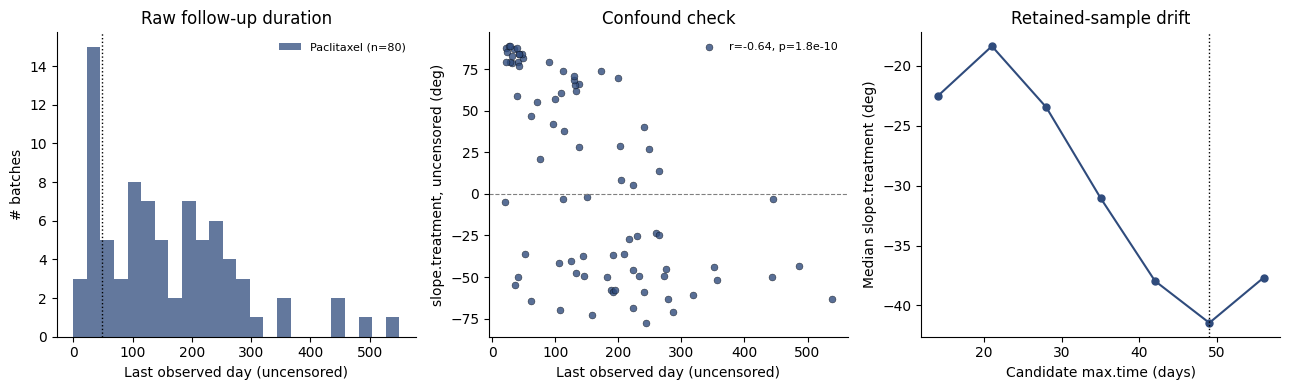

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Panel 1: raw follow-up duration (identical to the angle version above --
# follow-up duration doesn't depend on which response quantity is checked)
ax = axes[0]
ax.hist(pax_followup["last_observed_day"], bins=bins, alpha=0.75, color=PAX_COLOR,
        label=f"Paclitaxel (n={len(pax_followup)})")
ax.axvline(CHOSEN_MAX_TIME, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("Last observed day (uncensored)")
ax.set_ylabel("# batches")
ax.set_title("Raw follow-up duration")
ax.legend(frameon=False, fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel 2: confound check -- uncensored slope.treatment vs. follow-up day
ax = axes[1]
m = pax_followup.merge(pax_full_duration, on="batch.name").dropna(subset=["last_observed_day", "slope.treatment"])
rho, p = spearmanr(m["last_observed_day"], m["slope.treatment"])
ax.scatter(m["last_observed_day"], m["slope.treatment"], color=PAX_COLOR,
           edgecolor="black", linewidth=0.3, s=25, alpha=0.8, label=f"r={rho:.2f}, p={p:.1e}")
print(f"Uncensored slope.treatment vs. follow-up day: rho={rho:.3f}, p={p:.2e}, n={len(m)}")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Last observed day (uncensored)")
ax.set_ylabel("slope.treatment, uncensored (deg)")
ax.set_title("Confound check")
ax.legend(frameon=False, fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel 3: retained-sample median drift across the weekly max.time sweep
ax = axes[2]
drift_slope = pax_sweep.groupby("max_time")["slope.treatment"].median()
ax.plot(drift_slope.index, drift_slope.values, color=PAX_COLOR, marker="o", markersize=5)
ax.axvline(CHOSEN_MAX_TIME, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("Candidate max.time (days)")
ax.set_ylabel("Median slope.treatment (deg)")
ax.set_title("Retained-sample drift")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
out_path = paths["figures"] / "case4_window_confound_diagnostic_slope_treatment.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

### Apply the chosen response window (min.time=10, max.time=49)

Based on the diagnostic above -- both `angle` (peak, 112.4 degrees) and `slope.treatment` (trough, -41.5 degrees) reach their most extreme median value at max.time = 49 days, then erode back toward non-responding at wider windows as regrowth/relapse dynamics increasingly get folded in -- recompute slope/angle/mRECIST with `recompute_sensitivity_min10_max49.R` and apply them to `pax` and the RNA/CNV/mutation tables already built above, replacing the as-extracted values from `0_xevaset_extraction/`, which reflected the full, highly variable observed treatment duration. This mirrors case 3's own deepest-point selection (McGill's 28-day window) rather than a stabilization-based choice. This is the single place the window choice is applied for case study 4; `2-ML.ipynb` and `3-figures.ipynb` read the resulting `metadata.csv`/`rna_logtpm.csv`/`cnv.csv`/`mutation.csv` downstream.

In [9]:
import subprocess

subprocess.run(["Rscript", "recompute_sensitivity_min10_max49.R"], check=True)

batch_sens_new = pd.read_csv(paths["proc"] / "paclitaxel_batch_sensitivity_min10_max49.csv")
model_sens_new = pd.read_csv(paths["proc"] / "paclitaxel_model_sensitivity_min10_max49.csv")

batch_sens_new["model.id"] = batch_sens_new["batch.name"].str.split(".").str[0]
mask = batch_sens_new["model.id"].str.match(r'^\d', na=False)
batch_sens_new.loc[mask, "model.id"] = "S" + batch_sens_new.loc[mask, "model.id"]

# Same majority-vote aggregation as the "Drug sensitivity info extraction" section
# above (MRECIST_WORST_FIRST / majority_vote_mrecist / treatment_arm are already
# defined there), just fed the freshly-windowed per-mouse mRECIST calls.
mouse_mrecist_new = treatment_arm.merge(model_sens_new[["model.id", "mRECIST"]], on="model.id", how="left")
mrecist_derived_new = (
    mouse_mrecist_new.groupby("batch.name")["mRECIST"]
    .apply(majority_vote_mrecist)
    .rename("mRECIST")
    .reset_index()
)

pax_new = batch_sens_new.merge(mrecist_derived_new, on="batch.name", how="left")
pax_new = pax_new[["model.id", "angle", "slope.treatment", "mRECIST"]].set_index("model.id")

assert set(pax_new.index) == set(pax.index), "windowed recompute changed the paclitaxel model set"

print("mRECIST, old (full-duration) window:")
print(pax["mRECIST"].value_counts())
print("\nmRECIST, new (10-49 day) window:")
print(pax_new["mRECIST"].value_counts())
print(f"\nangle, old median: {pax['angle'].median():.1f}  new median: {pax_new['angle'].median():.1f}")
print(f"slope.treatment, old median: {pax['slope.treatment'].median():.1f}  new median: {pax_new['slope.treatment'].median():.1f}")
print(f"slope.treatment, new: {(pax_new['slope.treatment'] < 0).sum()}/{len(pax_new)} models < 0 deg (Sensitive under the fixed cutoff)")

pax = pax_new
pax.to_csv(metadata_out)

# Patch the already-saved RNA/CNV/mutation tables' response columns with the new
# windowed values. Row sets are unchanged (same 80 paclitaxel models, same omics
# availability) -- only angle/slope.treatment/mRECIST values differ -- so each
# already-filtered feature matrix just needs its response columns swapped, not
# full re-derivation.
for name, out_path in [("RNA", rna_out), ("CNV", cnv_out), ("Mutation", mutation_out)]:
    prior = pd.read_csv(out_path, index_col=0)
    X_only = prior.drop(columns=["angle", "slope.treatment", "mRECIST"])
    updated = X_only.merge(pax, left_index=True, right_index=True, how="inner")
    updated.to_csv(out_path)
    print(f"{name}: {out_path.name} updated ({updated.shape[0]} models, angle/slope.treatment/mRECIST refreshed)")

Warning message:
package ‘Xeva’ was built under R version 4.4.3 


There were 50 or more warnings (use warnings() to see the first 50)


Saved: ../data/procdata/4_paclitaxel/paclitaxel_batch_sensitivity_min10_max49.csv ( 80 batches )
Saved: ../data/procdata/4_paclitaxel/paclitaxel_model_sensitivity_min10_max49.csv ( 237 models )


mRECIST, old (full-duration) window:
mRECIST
SD    29
CR    22
PD    18
PR    11
Name: count, dtype: int64

mRECIST, new (10-49 day) window:
mRECIST
SD    33
PD    19
PR    14
CR    14
Name: count, dtype: int64

angle, old median: 68.2  new median: 112.4
slope.treatment, old median: 1.7  new median: -41.5
slope.treatment, new: 47/80 models < 0 deg (Sensitive under the fixed cutoff)


RNA: rna_logtpm.csv updated (67 models, angle/slope.treatment/mRECIST refreshed)


CNV: cnv.csv updated (62 models, angle/slope.treatment/mRECIST refreshed)
Mutation: mutation.csv updated (62 models, angle/slope.treatment/mRECIST refreshed)


### Response distribution: for reference -- is there a natural bimodal split?

Both `angle` and `slope.treatment` (now on the chosen 10-49 day window) show visible bimodal structure, with a natural gap that sits away from the median. The actual response label used for modeling is a **fixed slope.treatment < 0 deg cutoff**, matching case 3's convention (net tumor regression = responding) rather than either the median or the empirical gap -- so this isn't the basis for the cutoff, just useful context for where the fixed 0 deg threshold and the data's own clustering structure line up.

angle (deg): n=80, median=112.4, largest gap=16.3 degrees between 52.7 and 69.0 (midpoint 60.9), 31/80 values below the gap


slope.treatment (deg): n=80, median=-41.5, largest gap=14.3 degrees between -24.0 and -9.7 (midpoint -16.9), 45/80 values below the gap


Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/case4_response_distribution_natural_split_check.png


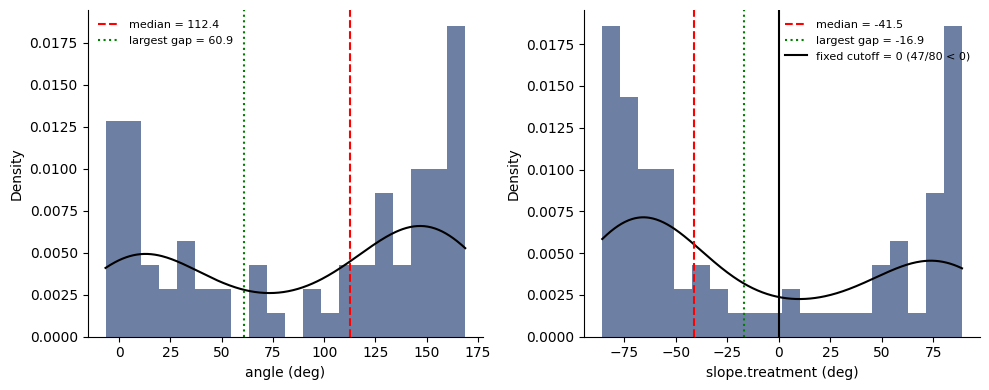

In [10]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, source_df, label, fixed_cutoff in [
    (axes[0], "angle", pax.reset_index(), "angle (deg)", None),
    (axes[1], "slope.treatment", batch_sens_new, "slope.treatment (deg)", 0),
]:
    vals = source_df[col].dropna().to_numpy()
    med = np.median(vals)
    ax.hist(vals, bins=20, color=PAX_COLOR, alpha=0.7, density=True)

    # KDE overlay to help visually assess bimodality
    kde = gaussian_kde(vals)
    xs = np.linspace(vals.min(), vals.max(), 300)
    ax.plot(xs, kde(xs), color="black", linewidth=1.5)

    # Largest-gap diagnostic: sort values, find the biggest jump between
    # consecutive points -- a real bimodal split should show a wide gap
    # roughly in the middle of the range, not just sparse tails.
    sorted_vals = np.sort(vals)
    gaps = np.diff(sorted_vals)
    i_max = int(np.argmax(gaps))
    gap_lo, gap_hi = sorted_vals[i_max], sorted_vals[i_max + 1]
    gap_mid = (gap_lo + gap_hi) / 2
    print(f"{label}: n={len(vals)}, median={med:.1f}, largest gap={gaps[i_max]:.1f} degrees "
          f"between {gap_lo:.1f} and {gap_hi:.1f} (midpoint {gap_mid:.1f}), "
          f"{i_max + 1}/{len(vals)} values below the gap")

    ax.axvline(med, color="red", linestyle="--", linewidth=1.5, label=f"median = {med:.1f}")
    ax.axvline(gap_mid, color="green", linestyle=":", linewidth=1.5, label=f"largest gap = {gap_mid:.1f}")
    if fixed_cutoff is not None:
        n_below = int((vals < fixed_cutoff).sum())
        ax.axvline(fixed_cutoff, color="black", linestyle="-", linewidth=1.5,
                    label=f"fixed cutoff = {fixed_cutoff} ({n_below}/{len(vals)} < 0)")
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.legend(frameon=False, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
out_path = paths["figures"] / "case4_response_distribution_natural_split_check.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

### Summary: sample sizes and omics overlap

In [11]:
rna_raw_n = pd.read_csv(rna_file, index_col=0, nrows=1).shape[1]
cnv_raw_n = pd.read_csv(cnv_file, index_col=0, nrows=1).shape[1]
mutation_raw_n = pd.read_csv(mutation_file, index_col=0, nrows=1).shape[1]

rna_final = pd.read_csv(rna_out, index_col=0)
cnv_final = pd.read_csv(cnv_out, index_col=0)
mutation_final = pd.read_csv(mutation_out, index_col=0)

print(f"{'':22s}{'raw total':>12s}{'∩ pax':>12s}")
print(f"{'pax (paclitaxel)':22s}{'--':>12s}{len(pax):>12d}")
print(f"{'RNA-seq':22s}{rna_raw_n:>12d}{len(rna_final):>12d}")
print(f"{'CNV':22s}{cnv_raw_n:>12d}{len(cnv_final):>12d}")
print(f"{'Mutation':22s}{mutation_raw_n:>12d}{len(mutation_final):>12d}")

cnv_mut_same = set(cnv_final.index) == set(mutation_final.index)
print(f"\nCNV and Mutation cover the identical model set: {cnv_mut_same}")

rna_only = sorted(set(rna_final.index) - set(cnv_final.index))
three_way = set(rna_final.index) & set(cnv_final.index) & set(mutation_final.index)
print(f"RNA-only models (no CNV/Mutation data): {rna_only}")
print(f"\nTrue 3-way overlap (RNA & CNV & Mutation): {len(three_way)} models")
print("-> this is the cohort available for early/late fusion in 2-ML.ipynb")

                         raw total       ∩ pax
pax (paclitaxel)                --          80
RNA-seq                         95          67
CNV                             91          62
Mutation                        91          62

CNV and Mutation cover the identical model set: True
RNA-only models (no CNV/Mutation data): ['NOTCH01', 'NOTCH06', 'NOTCH10', 'NOTCH18', 'NOTCHB02']

True 3-way overlap (RNA & CNV & Mutation): 62 models
-> this is the cohort available for early/late fusion in 2-ML.ipynb


### Intrinsic molecular subtype (PAM50-equivalent, AIMS)

No clinical ER/PR/HER2 IHC annotation exists anywhere in the UHN breast XevaSet (`models.csv`, the XevaSet's model slot, and `0_xevaset_extraction/` were all checked), so intrinsic molecular subtype is derived directly from RNA-seq via AIMS (Absolute Intrinsic Molecular Subtyping, Paquet & Hallett 2015, *JNCI*) -- a single-sample, rank-based classifier that reports the same five PAM50 labels (Basal, Her2, LumA, LumB, Normal) without requiring a reference cohort for centering (`genefu`'s centroid-based PAM50 isn't installed, and wouldn't be an obvious fit here anyway given there's no matched normal/reference panel to center against). Computed once in `compute_pam50_subtype_aims.R` from the paclitaxel cohort's `rna_logtpm.csv` and saved to `results/4_paclitaxel/`.

In [ ]:
import subprocess

subprocess.run(["Rscript", "compute_pam50_subtype_aims.R"], check=True)

subtype = pd.read_csv(paths["results"] / "uhn_breast_pam50_aims_subtype.csv")
print(f"Models subtyped: {len(subtype)}")
print(subtype["subtype"].value_counts())
print(f"\nMedian classification confidence: {subtype['confidence'].median():.3f}")
print(f"Models with confidence < 0.9: {(subtype['confidence'] < 0.9).sum()}")